In [79]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pyro.infer import MCMC, NUTS
import torch
from pyro.infer import Predictive
from pyro.distributions import Normal, Categorical

import pandas as pd
import pymc as pm
import pytensor

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

## Simulate Data

In [12]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [96]:
def create_data(c_params, n_samples, n_features, n_bias_features):
    features_obs = np.random.uniform(0, 1, size=(n_samples, n_features))
    amount = np.random.uniform(0, 2,size=(n_samples))
    logit_bias = c_params[-1] + np.matmul(features_obs[:, 0:n_bias_features], c_params[0:n_bias_features])
    logit_quant = c_params[n_bias_features]*np.multiply(features_obs[:, n_bias_features], amount) -  c_params[n_bias_features+1]*np.multiply(features_obs[:, n_bias_features + 1], amount ** 2)
    probs_obs = sigmoid(logit_bias + logit_quant)
    y_obs = np.random.binomial(1, probs_obs)
    x_obs = np.hstack((features_obs, amount.reshape(-1, 1)))
    x = torch.from_numpy(x_obs).float()
    y = torch.from_numpy(y_obs).float()

    return x, y, probs_obs


c_params = [ -4,2,3,3,1,-3 ]
n_bias_features = 3
n_features = 5
n_samples_train= 20000
n_samples_val= 2000
n_samples_test= 20000

# train
x_train, y_train, probs_obs_train = create_data(c_params, n_samples_train, n_features, n_bias_features)
x_val, y_val, probs_obs_val = create_data(c_params, n_samples_train, n_features, n_bias_features)
x_test, y_test, probs_obs_test = create_data(c_params, n_samples_test, n_features, n_bias_features)

# test
# x_obs_test = np.random.uniform(0, 1, size=(n_users, num_features))
# probs_obs_test = sigmoid(c_params[0] + np.matmul(x_obs_test, c_params[1:]))
# y_obs_test = np.random.binomial(1, probs_obs_test)



In [97]:
probs_obs_train

array([0.09798183, 0.69060588, 0.66599318, ..., 0.75756174, 0.02876168,
       0.006949  ])

In [68]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn


class BNN(PyroModule):
    def __init__(self, in_dim=n_features, out_dim=1, hid_dim=10, prior_scale=5.):
        super().__init__()

        self.activation = nn.Tanh()  # or nn.ReLU()
        self.layer1 = PyroModule[nn.Linear](in_dim, hid_dim)  # Input to hidden layer
        self.layer2 = PyroModule[nn.Linear](hid_dim, out_dim)  # Hidden to output layer

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, in_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

    def forward(self, x, y=None):
        #x = x.reshape(-1, 1)
        x = self.activation(self.layer1(x))
        logits = self.layer2(x).squeeze()

        # Sampling model
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        return logits

In [98]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class BNN(nn.Module):
    def __init__(self, in_dim, out_dim=1, hid_dim=10):
        super(BNN, self).__init__()

        self.activation = nn.Tanh()  # or nn.ReLU()
        self.layer1 = nn.Linear(in_dim, hid_dim)  # Input to hidden layer
        self.layer2 = nn.Linear(hid_dim, out_dim)  # Hidden to output layer

    def forward(self, x):
        x = self.activation(self.layer1(x))
        logits = self.layer2(x).squeeze()
        return logits


In [84]:

# def model(x_data, y_data, net, prior_scale=5.):
#
#     layer1_w_prior = Normal(loc=torch.zeros_like(net.layer1.weight), scale=torch.ones_like(net.layer1.weight) * prior_scale)
#     layer1_b_prior = Normal(loc=torch.zeros_like(net.layer1.bias), scale=torch.ones_like(net.layer1.bias) * prior_scale)
#
#     layer2_w_prior = Normal(loc=torch.zeros_like(net.layer2.weight), scale=torch.ones_like(net.layer2.weight) * prior_scale)
#     layer2_b_prior = Normal(loc=torch.zeros_like(net.layer2.bias), scale=torch.ones_like(net.layer2.bias) * prior_scale)
#
#
#     priors = {'layer1.weight': layer1_w_prior, 'layer1.bias': layer1_b_prior,  'layer2.weight': layer2_w_prior, 'layer2.bias': layer2_b_prior}
#
#     # lift module parameters to random variables sampled from the priors
#     lifted_module = pyro.random_module("module", net, priors)
#     # sample a regressor (which also samples w and b)
#     lifted_reg_model = lifted_module()
#
#     logits = lifted_reg_model(x_data)
#     pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y_data)


In [116]:
def model(x, y , in_dim, hid_dim, out_dim=1, prior_scale=1.0):
    # Priors for layer 1 weights and biases
    layer1_weight = pyro.sample("layer1_weight", dist.Normal(0., prior_scale).expand([hid_dim, in_dim]).to_event(2))
    layer1_bias = pyro.sample("layer1_bias", dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))

    # Priors for layer 2 weights and biases
    layer2_weight = pyro.sample("layer2_weight", dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
    layer2_bias = pyro.sample("layer2_bias", dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

    priors = {'layer1.weight': layer1_weight, 'layer1.bias': layer1_bias, 'layer2.weight': layer2_weight, 'layer2.bias': layer2_bias}
    # Create an instance of the BNN class
    bnn = BNN(in_dim, out_dim, hid_dim)
    lifted_module = pyro.random_module("module", bnn, priors)
    lifted_reg_model = lifted_module()


    # Likelihood of observed data
    with pyro.plate("data", len(y)):
        pyro.sample("obs", dist.Bernoulli(logits=lifted_reg_model(x)), obs=y)


In [117]:
def guide(x,y, in_dim, hid_dim, out_dim=1, prior_scale=1.0):
    # Variational parameters for layer 1 weights and biases
    layer1_weight_loc = pyro.param("layer1_weight_loc", torch.randn(hid_dim, in_dim))
    layer1_weight_scale = pyro.param("layer1_weight_scale", torch.ones(hid_dim, in_dim), constraint=dist.constraints.positive)
    layer1_bias_loc = pyro.param("layer1_bias_loc", torch.randn(hid_dim))
    layer1_bias_scale = pyro.param("layer1_bias_scale", torch.ones(hid_dim), constraint=dist.constraints.positive)

    # Variational parameters for layer 2 weights and biases
    layer2_weight_loc = pyro.param("layer2_weight_loc", torch.randn(out_dim, hid_dim))
    layer2_weight_scale = pyro.param("layer2_weight_scale", torch.ones(out_dim, hid_dim), constraint=dist.constraints.positive)
    layer2_bias_loc = pyro.param("layer2_bias_loc", torch.randn(out_dim))
    layer2_bias_scale = pyro.param("layer2_bias_scale", torch.ones(out_dim), constraint=dist.constraints.positive)

    # Sample from the variational distributions
    pyro.sample("layer1_weight", dist.Normal(layer1_weight_loc, layer1_weight_scale).to_event(2))
    pyro.sample("layer1_bias", dist.Normal(layer1_bias_loc, layer1_bias_scale).to_event(1))
    pyro.sample("layer2_weight", dist.Normal(layer2_weight_loc, layer2_weight_scale).to_event(2))
    pyro.sample("layer2_bias", dist.Normal(layer2_bias_loc, layer2_bias_scale).to_event(1))

# variational inference

## Using Pyro's SVI

In [118]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
pyro.clear_param_store()

#deep_model = BNN(in_dim=n_features)
optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store()

num_epochs = 1000
progress_bar = trange(num_epochs)
loss_list = []
for epoch in progress_bar:
    loss = svi.step(x_train, y_train, in_dim=n_features + 1, hid_dim = 10, prior_scale=5.0)

    # claculate preds for train/val data (ADD)
    loss_list.append(loss)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

  0%|          | 0/1000 [00:00<?, ?it/s]/home/ronshi/.conda/envs/pybandits/lib/python3.9/site-packages/pyro/poutine/lift_messenger.py:74: UserWarning: pyro.module prior did not find params ['layer2.weight', 'layer1.bias', 'layer2.bias']. Did you instead mean one of ['']?
  warnings.warn(
  0%|          | 0/1000 [00:00<?, ?it/s]


TypeError: 'Tensor' object is not callable

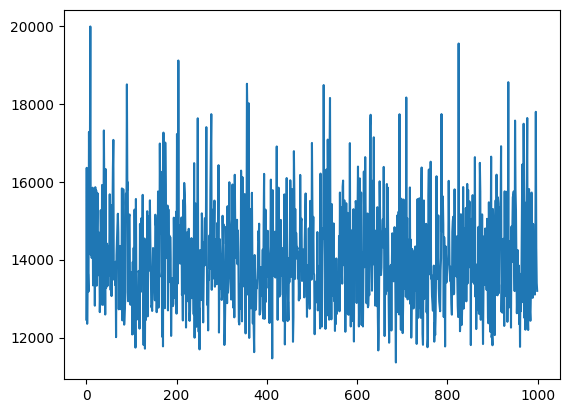

In [115]:
plt.figure()
plt.plot(loss_list)

## check parameters and logits

In [111]:
predictive = Predictive(deep_model, guide=mean_field_guide, num_samples=1000,
                        return_sites=("layer1.weight", "layer1.bias", "obs", "_RETURN"))
samples = predictive(x_train)
logits = samples['_RETURN'].squeeze()

ValueError: tensor([[0.1914, 0.7678, 0.6484, 0.0044, 0.6867, 1.6881],
        [0.0201, 0.8921, 0.3941, 0.6542, 0.6960, 0.5911],
        [0.4752, 0.5053, 0.9141, 0.8441, 0.8431, 1.2268],
        ...,
        [0.1628, 0.2522, 0.9323, 0.7689, 0.6996, 0.8808],
        [0.9360, 0.3662, 0.7394, 0.7265, 0.0982, 0.1263],
        [0.9445, 0.5035, 0.6601, 0.1144, 0.6167, 1.6843]]) is not callable, did you mean to pass it as a keyword arg?
Trace Shapes:
 Param Sites:
Sample Sites:

0.39765411506052983
tensor(0.3608)
0.27410293842295763
tensor(0.2079)
0.08948840504759141
tensor(0.0454)
0.0813813809146647
tensor(0.0805)
0.4776842753802937
tensor(0.4836)


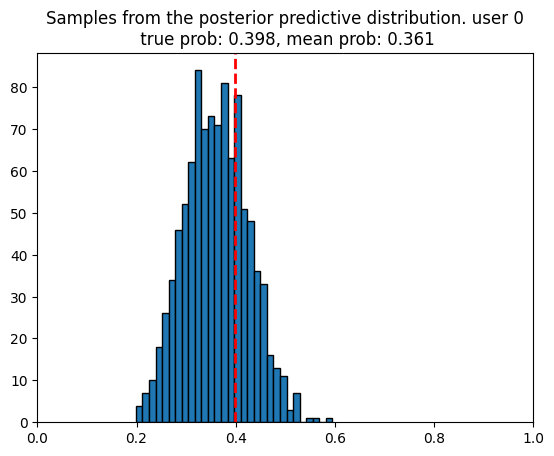

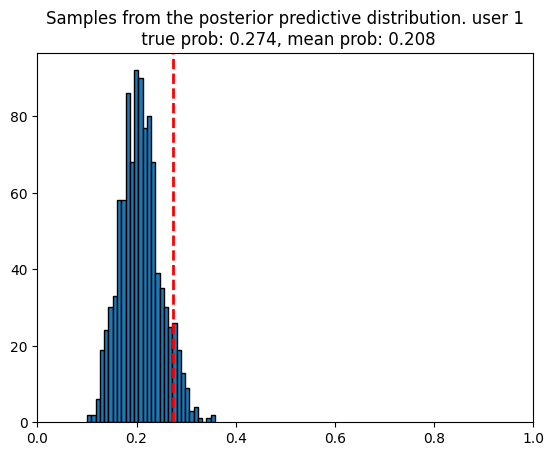

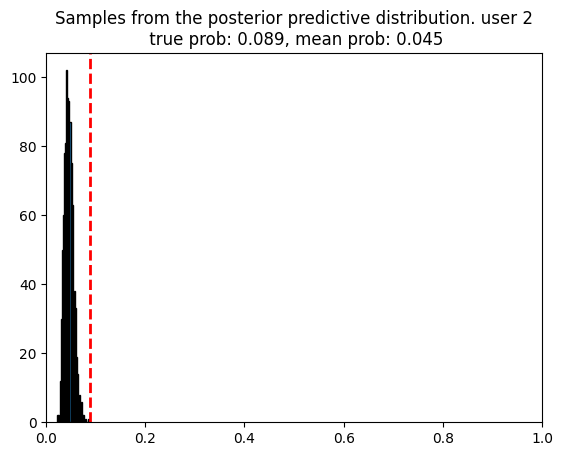

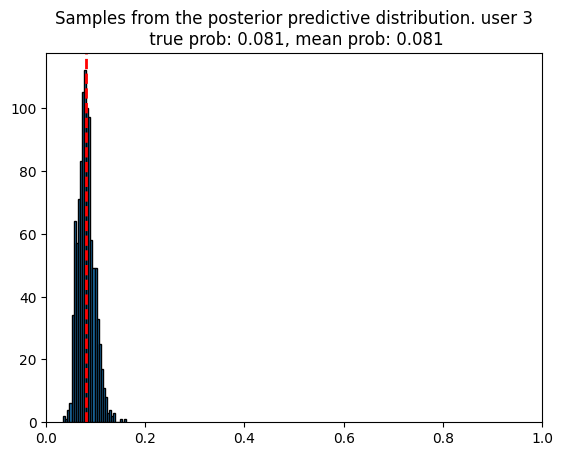

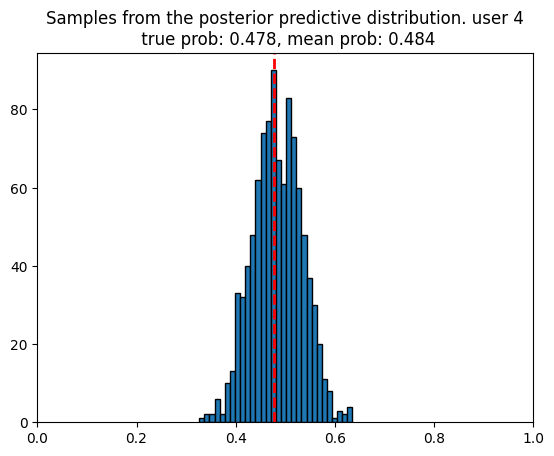

In [72]:
for ind in range(5):
    curr_pred = probs_obs_train[ind]

    preds_from_model = sigmoid(logits[:,ind])

    print(curr_pred)
    print(preds_from_model.mean())
    plt.figure()
    plt.hist(preds_from_model, bins=30, edgecolor='black')
    plt.axvline(x=curr_pred, color='r', linestyle='--', linewidth=2)
    plt.xlim(0, 1)
    plt.title(f'Samples from the posterior predictive distribution. user {ind}\n true prob: {curr_pred:.3f}, mean prob: {preds_from_model.mean():.3f}')


## check test data

In [73]:

samples_test = predictive(x_test)
logits_test = samples_test['_RETURN'].squeeze()


0.17909605740852286
tensor(0.1685)
0.7399823245042068
tensor(0.7079)
0.7965285908224862
tensor(0.7246)
0.5992452430826919
tensor(0.7026)
0.03957400047829393
tensor(0.0165)
0.654908918926262
tensor(0.5290)
0.6711063764258454
tensor(0.6242)
0.06866134591362598
tensor(0.0657)
0.3524289375324518
tensor(0.2558)
0.010857014571229654
tensor(0.0118)


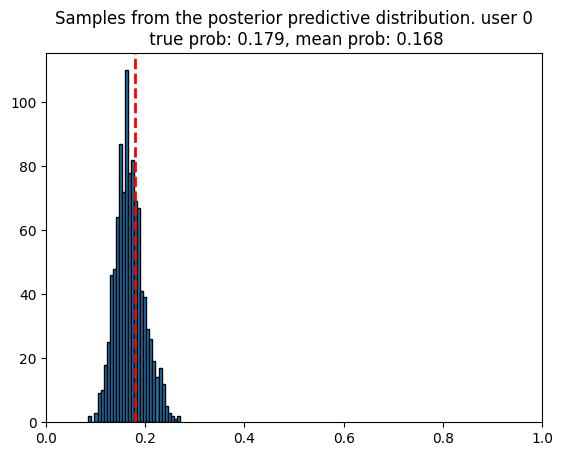

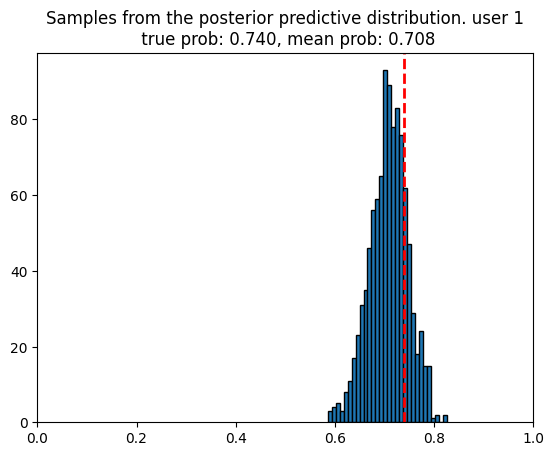

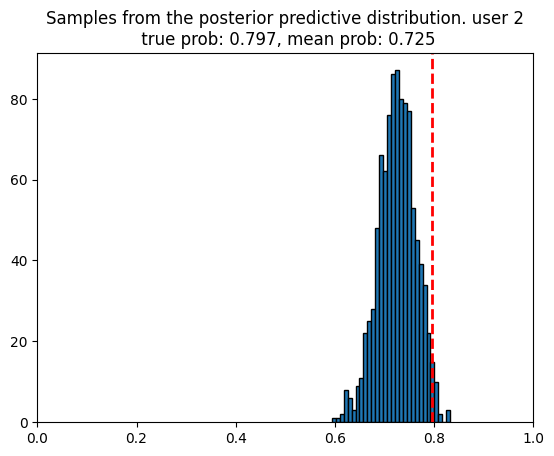

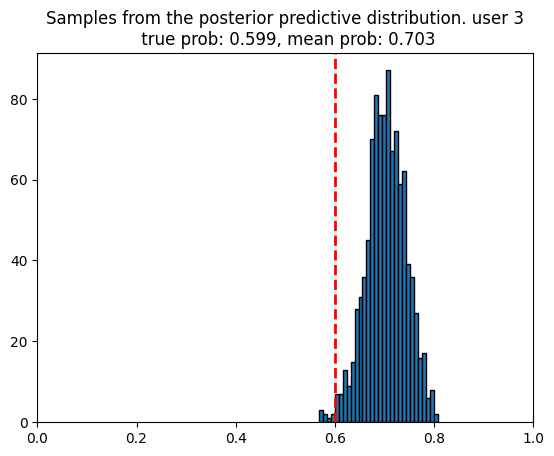

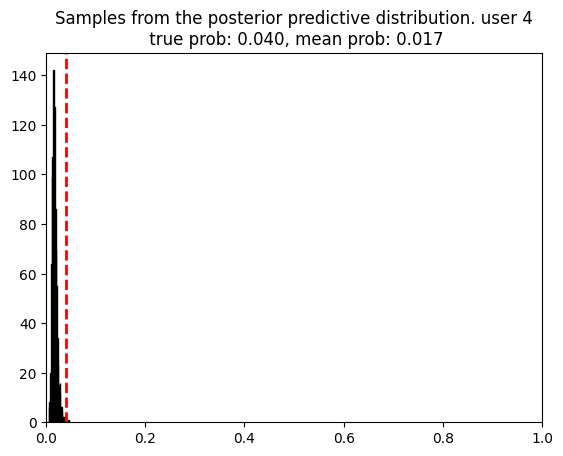

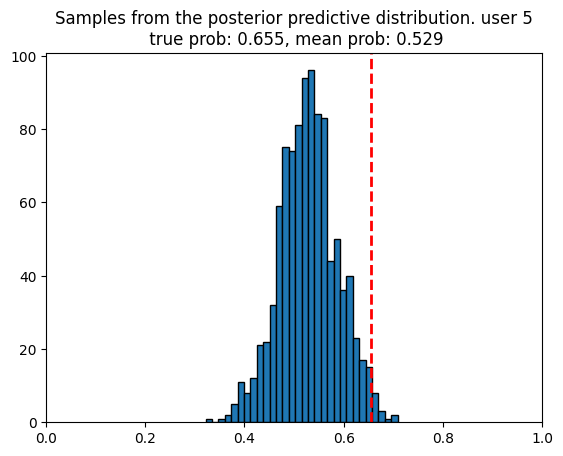

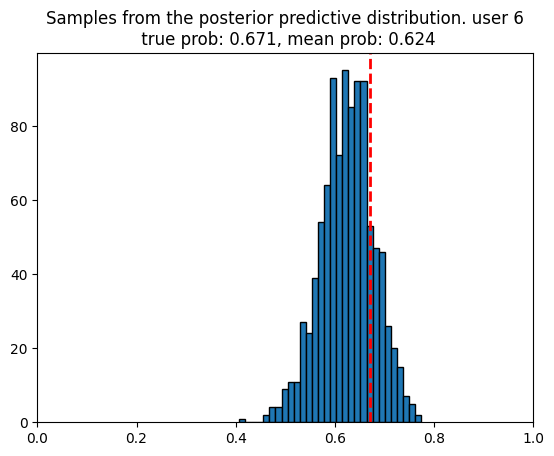

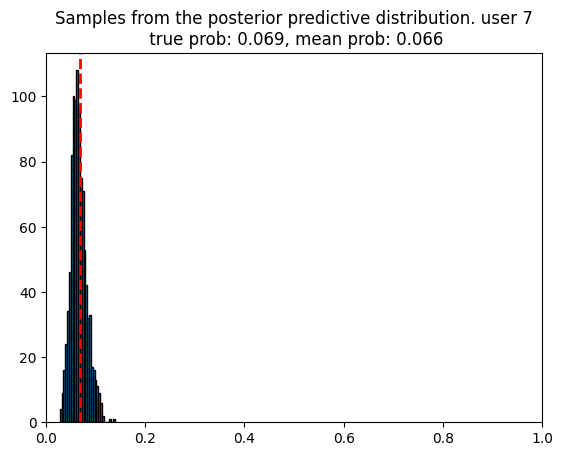

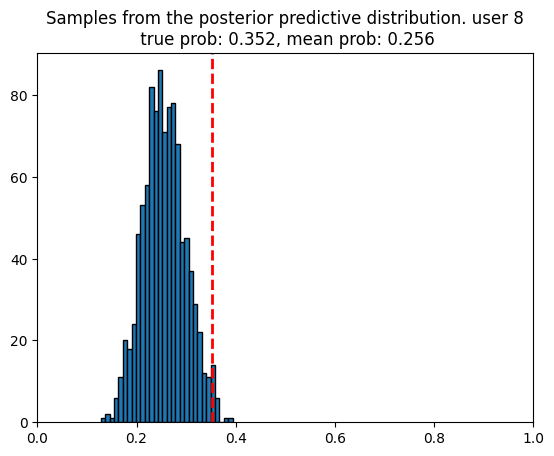

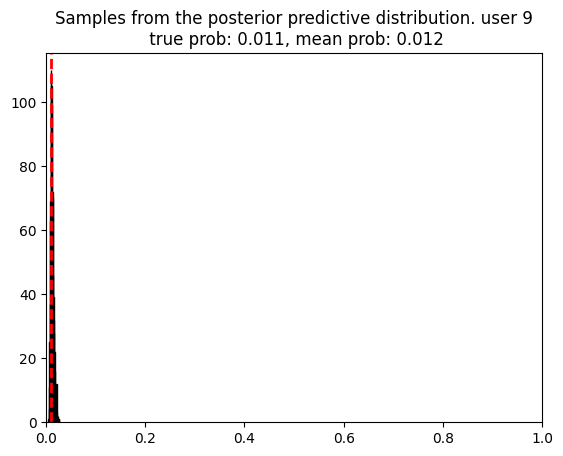

In [74]:
for ind in range(10):
    curr_pred = probs_obs_test[ind]

    preds_from_model = sigmoid(logits_test[:,ind])

    print(curr_pred)
    print(preds_from_model.mean())
    plt.figure()
    plt.hist(preds_from_model, bins=30, edgecolor='black')
    plt.axvline(x=curr_pred, color='r', linestyle='--', linewidth=2)
    plt.xlim(0, 1)
    plt.title(f'Samples from the posterior predictive distribution. user {ind}\n true prob: {curr_pred:.3f}, mean prob: {preds_from_model.mean():.3f}')


In [ ]:
### Given a trained model - find optimal quantity

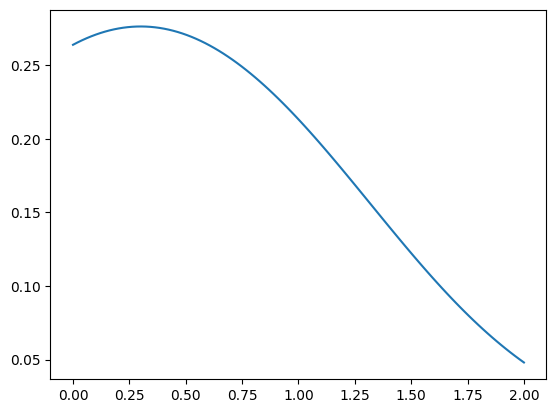

In [78]:
# first user:
ind = 1
xx = x_train[ind,:]
amount = np.linspace(0, 2, 100)
logit_bias = c_params[0] + np.matmul(xx[0:n_bias_features], c_params[1:])
logit_quant = np.multiply(xx[n_bias_features], amount) - np.multiply(xx[n_bias_features + 1], amount ** 2)
probs = sigmoid(logit_bias + logit_quant)
probs
plt.figure()
plt.plot(amount, probs)


In [ ]:
mean_field_guide()

## Simple BNN

In [66]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn


class Simple_BNN(PyroModule):
    def __init__(self, in_dim=num_features, out_dim=1, hid_dim=10, prior_scale=5.):
        super().__init__()

        self.layer1 = PyroModule[nn.Linear](in_dim, out_dim)

        # Set layer parameters as random variables
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, in_dim, ]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))


    def forward(self, x, y=None):
        #x = x.reshape(-1, 1)
        logits = self.layer1(x).squeeze()

        # Sampling model
        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        return logits

In [68]:
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from tqdm.auto import trange
pyro.clear_param_store()

#model = BNN(hid_dim=10, n_hid_layers=5, prior_scale=5.)
model = Simple_BNN(in_dim=num_features)
mean_field_guide = AutoDiagonalNormal(model)
optimizer = pyro.optim.Adam({"lr": 0.01})

svi = SVI(model, mean_field_guide, optimizer, loss=Trace_ELBO())
pyro.clear_param_store()

num_epochs = 10000
progress_bar = trange(num_epochs)
loss_list = []
for epoch in progress_bar:
    loss = svi.step(x_train, y_train)
    loss_list.append(loss)
    progress_bar.set_postfix(loss=f"{loss / x_train.shape[0]:.3f}")

100%|██████████| 10000/10000 [01:26<00:00, 116.12it/s, loss=0.375]


## check parameters

In [81]:
predictive = Predictive(model, guide=mean_field_guide, num_samples=1000,
                        return_sites=("layer1.weight","layer1.bias",  "obs", "_RETURN"))
samples = predictive(x_train)

In [85]:
samples['layer1.weight'].squeeze()

tensor([[-5.1278,  2.0692,  2.7831],
        [-4.9906,  2.1065,  2.7627],
        [-4.9230,  2.0463,  2.7396],
        ...,
        [-5.0156,  2.1743,  2.7812],
        [-5.0338,  2.0542,  2.8160],
        [-5.0444,  2.0242,  2.7726]])

In [78]:
mean_field_guide.get_posterior().mean

Parameter containing:
tensor([-5.0106,  2.0551,  2.7915, -1.8419], requires_grad=True)

In [79]:
mean_field_guide.get_posterior().stddev

tensor([0.0657, 0.0463, 0.0439, 0.0283], grad_fn=<SqrtBackward0>)